In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [3]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

In [4]:
# ============================================================
# STEP 0–1 — LOAD → filter labels {0,1} → drop blacklist CpGs
#          → split 0.8/0.2 stratified → Edgar(β) on TRAIN only
#          → apply Edgar-selected CpGs to TRAIN+TEST (no leakage)
# ============================================================

import numpy as np
import polars as pl
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG (edit only these)
# -----------------------------
BETA_PATH = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"

BLACKLIST_PATH = "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse69914/removed_cpgs_all_filters_summary_gse69914.csv"
BLACKLIST_CPG_COL = "CpG_ID"

ID_COL = "id_tissue"
LABEL_COL = "label"
LABELS_USE = [0, 1]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# Edgar (β)
R_BETA_CUTOFF = 0.05

# -----------------------------
# HELPERS
# -----------------------------
def compute_r_beta_edgar(beta_df: pl.DataFrame, label_col: str, label_values, cpg_cols):
    """
    Edgar-like variability: r_beta = Q90 - Q10 computed on subset with label in label_values.
    """
    subset = beta_df.filter(pl.col(label_col).is_in(label_values))
    subset_cpg = subset.select(cpg_cols)
    q90 = subset_cpg.select(pl.all().quantile(0.90)).to_numpy()[0, :]
    q10 = subset_cpg.select(pl.all().quantile(0.10)).to_numpy()[0, :]
    return q90 - q10

# -----------------------------
# STEP 0 — LOAD + FILTER LABELS + DROP BLACKLIST CpGs
# -----------------------------
print("=" * 90)
print("STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs")
print("=" * 90)

# blacklist CpGs
bl = pl.read_csv(BLACKLIST_PATH)
black_cpgs_set = set(
    bl.select(pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)).unique().to_series().to_list()
)
print(f"Blacklist CpGs: {len(black_cpgs_set):,}")

# load beta parquet
beta = (
    pl.read_parquet(BETA_PATH)
    .filter(pl.col(LABEL_COL).is_in(LABELS_USE))
    .with_columns([
        pl.col(ID_COL).cast(pl.Utf8),
        pl.col(LABEL_COL).cast(pl.Int64),
    ])
)

# CpG columns: keep only cg/ch + ID/LABEL
cpg_cols_all = [c for c in beta.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
cpg_cols_set = set(cpg_cols_all)

# drop blacklist CpGs
to_drop_blacklist = [c for c in cpg_cols_all if c in black_cpgs_set]

# drop any other unexpected string columns (safety, keeps only ID, LABEL, CpGs)
to_drop_other = [
    c for c in beta.columns
    if isinstance(c, str) and (c not in cpg_cols_set) and (c not in (ID_COL, LABEL_COL))
]

beta = beta.drop(to_drop_blacklist + to_drop_other)

print(f"After label filter + drops: shape={beta.shape}")
print(f"CpGs kept (pre-split): {len([c for c in beta.columns if isinstance(c, str) and (c.startswith('cg') or c.startswith('ch'))]):,}")

# -----------------------------
# STEP 1 — SPLIT + EDGAR TRAIN-ONLY + APPLY TO BOTH
# -----------------------------
print("\n" + "=" * 90)
print("STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test")
print("=" * 90)

y_all = beta.select(LABEL_COL).to_numpy().ravel().astype(int)
idx_all = np.arange(beta.height)

tr_idx, te_idx = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# build split frames without copying CpG matrices yet
beta_idx = beta.with_row_count("_row_id")
beta_tr = beta_idx.filter(pl.col("_row_id").is_in(tr_idx.tolist())).drop("_row_id")
beta_te = beta_idx.filter(pl.col("_row_id").is_in(te_idx.tolist())).drop("_row_id")

print(f"Split sizes: train={beta_tr.height} | test={beta_te.height}")

# Edgar on TRAIN ONLY
cpg_cols_train = [c for c in beta_tr.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
r_beta = compute_r_beta_edgar(beta_tr, LABEL_COL, LABELS_USE, cpg_cols_train)

mask_keep = r_beta >= R_BETA_CUTOFF
cpg_cols_edgar = [cpg_cols_train[i] for i in range(len(cpg_cols_train)) if mask_keep[i]]

print(f"Edgar cutoff r_beta >= {R_BETA_CUTOFF}")
print(f"CpGs before Edgar: {len(cpg_cols_train):,}")
print(f"CpGs after  Edgar: {len(cpg_cols_edgar):,}  (dropped {len(cpg_cols_train) - len(cpg_cols_edgar):,})")

# Apply Edgar-selected CpGs to BOTH train and test (no leakage)
beta_tr = beta_tr.select([ID_COL, LABEL_COL] + cpg_cols_edgar)
beta_te = beta_te.select([ID_COL, LABEL_COL] + cpg_cols_edgar)

# Optionally expose matrices
B_train = beta_tr.select(cpg_cols_edgar).to_numpy().astype(np.float32)
B_test  = beta_te.select(cpg_cols_edgar).to_numpy().astype(np.float32)
y_train = beta_tr.select(LABEL_COL).to_numpy().ravel().astype(int)
y_test  = beta_te.select(LABEL_COL).to_numpy().ravel().astype(int)

print(f"Final matrices: B_train={B_train.shape} | B_test={B_test.shape}")
print("Done.")


STEP 0 — LOAD + filter labels {0,1} + drop blacklist CpGs
Blacklist CpGs: 234,029
After label filter + drops: shape=(92, 251485)
CpGs kept (pre-split): 251,483

STEP 1 — split 0.8/0.2 stratified + Edgar(β) train-only + apply CpGs to train/test
Split sizes: train=73 | test=19
Edgar cutoff r_beta >= 0.05
CpGs before Edgar: 251,483
CpGs after  Edgar: 151,380  (dropped 100,103)
Final matrices: B_train=(73, 151380) | B_test=(19, 151380)
Done.



Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: plots_outputs/GSE69914_edgar_variability.pdf


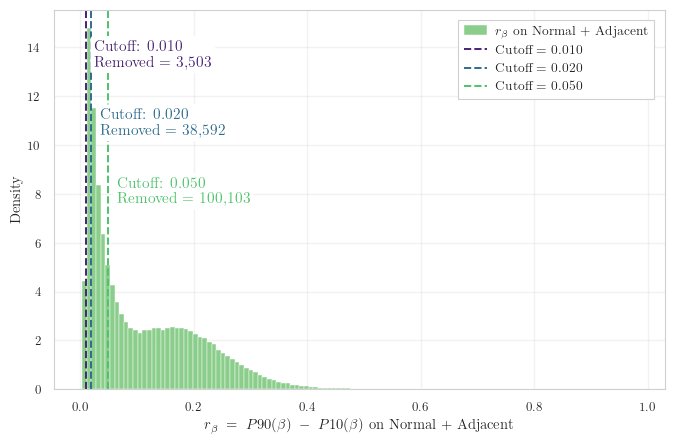

In [5]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF) — after fig exists
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE69914_edgar_variability.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [6]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep = sd >= thr
    return X[:, keep], cols[keep], sd[keep], keep

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 1 you have: B_train, B_test, beta_tr, beta_te, cpg_cols_edgar)
cols_full = np.array(cpg_cols_edgar, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cols_full, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cols_full = M_train_f, M_test_f, cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cols_full.copy()
else:
    cpg_cols_current = cols_full.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")



STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(73, 151380) | M_test=(19, 151380)
Variance filter: drop_frac=2.00%
CpGs before: 151,380 | after: 148,352  (dropped 3,028)
Current aligned: B_train=(73, 148352) | M_train=(73, 148352) | CpGs=148,352



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: plots_outputs/GSE69914_sdM_variance_filter.pdf


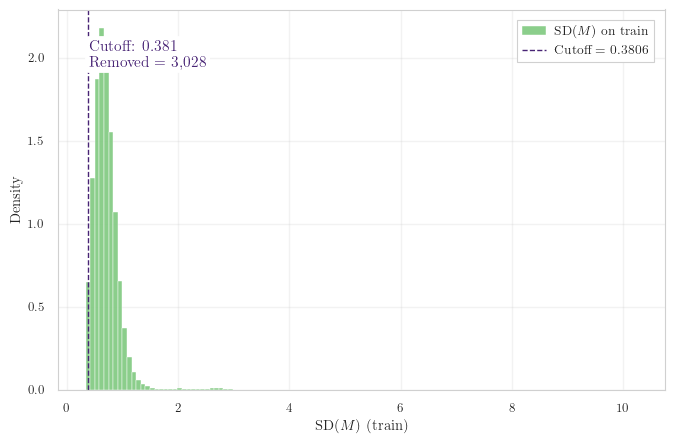

Kept = 145,324 / 148,352 CpGs (Removed = 3,028)


In [7]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)
removed = int((~keep_mask).sum())
kept = total - removed

fig, ax = plt.subplots()

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "GSE69914_sdM_variance_filter.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")


In [8]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
DELTA_M_THR_MAIN = 0.15
DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
mean_rank_p = rank_p_sum / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score
score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

# candidate filter with fallback
thr = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand = int(mask_cand.sum())
print(f"Candidates with |ΔM|>={thr:.2f} and stability_sign>={STABILITY_SIGN_MIN:.2f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    thr = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.2f}: candidates={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3 produced 0 candidates even after fallback. Lower thresholds or inspect data.")

# pick top 15k by score (lower is better)
cand_idx = np.where(mask_cand)[0]
order = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top = cand_idx_sorted[:min(TOP_CANDIDATES, cand_idx_sorted.size)]

cpg_candidates = cols[cand_idx_top]

# keep useful stats for later steps (region anchoring / reporting)
step3_stats = {
    "score": score[cand_idx_top],
    "mean_rank_p": mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM": mean_rank_dm[cand_idx_top],
    "stability_sign": stability_sign[cand_idx_top],
    "deltaM_full": dM_full[cand_idx_top],
    "abs_deltaM_full": abs_dM_full[cand_idx_top],
    "used_deltaM_thr": thr,
    "valid_splits_for_score": valid_splits_for_score,
    "sign_valid_splits": sign_valid_count[cand_idx_top],
}

print(f"Selected top candidates: {len(cpg_candidates):,} (target {TOP_CANDIDATES:,})")
print("Example:", cpg_candidates[:5].tolist())



STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=73 | p=148,352 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 | 


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: plots_outputs/GSE69914_stability_sign_distribution.pdf


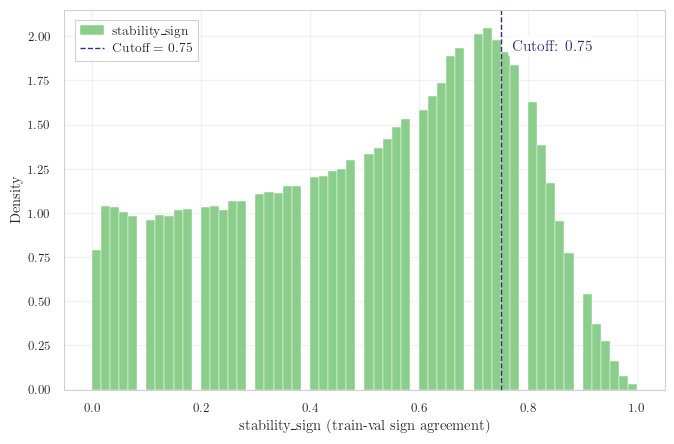

In [9]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_NAME = "GSE69914"   # <-- modifica se necessario

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel("stability_sign (train-val sign agreement)")
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()



STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: plots_outputs/GSE69914_absDeltaM_vs_score.pdf


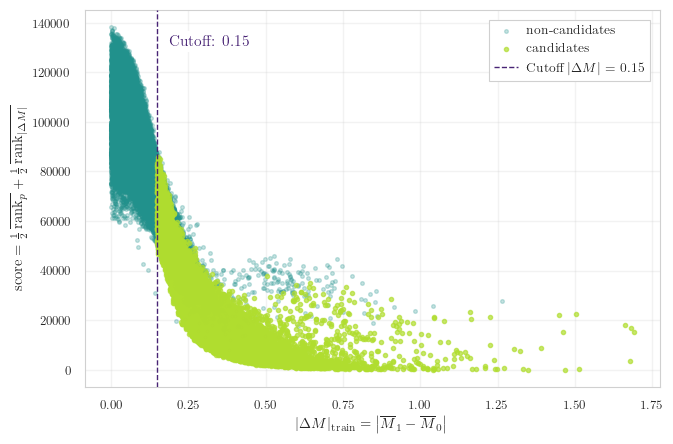

In [10]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / f"{DATASET_NAME}_absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()


In [11]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")



STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.8684 | p-value = 0.000e+00 | n = 148,352
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.9199 | p-value = 0.000e+00 | n = 26,014
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [16]:
# =============================
# MANIFEST → build context and region mapping (CORRECTED)
# =============================

import pandas as pd
import polars as pl

print("\n" + "=" * 90)
print("MANIFEST loading — build CpG context mapping")
print("=" * 90)

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"


def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Cannot find 'IlmnID' header in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

# load manifest
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# check available columns (safety print once)
print("Manifest columns:", mf_pd.columns.tolist()[:10], "...")

# convert to polars with explicit column names
mf = pl.from_pandas(mf_pd).select([
    pl.col("IlmnID").cast(pl.Utf8).alias("cpg"),
    pl.col("CHR").cast(pl.Utf8).alias("chr"),
    pl.col("MAPINFO").cast(pl.Int64).alias("pos"),
    pl.col("Relation_to_UCSC_CpG_Island").cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# keep only STEP 3 candidates
mf = mf.filter(pl.col("cpg").is_in(cpg_candidates.tolist()))

# build mappings
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# optional region binning (1kb bins for Island/Shore)
cpg_to_region = {}
for c, ch, pos, ctx in zip(
    mf["cpg"].to_list(),
    mf["chr"].to_list(),
    mf["pos"].to_list(),
    mf["ctx"].to_list()
):
    if ctx in ["Island", "Shore"] and ch != "" and pos is not None:
        region_id = f"{ch}:{pos//1000}"
        cpg_to_region[c] = region_id

print(f"Context mapping built for {len(cpg_to_ctx):,} CpGs")
print(f"Region mapping built for {len(cpg_to_region):,} CpGs")



MANIFEST loading — build CpG context mapping
Manifest columns: ['IlmnID', 'Name', 'AddressA_ID', 'AlleleA_ProbeSeq', 'AddressB_ID', 'AlleleB_ProbeSeq', 'Infinium_Design_Type', 'Next_Base', 'Color_Channel', 'Forward_Sequence'] ...
Context mapping built for 15,000 CpGs
Region mapping built for 5,059 CpGs


In [17]:
# =============================
# STEP 3b — Region anchoring su CpG Islands/Shores (DIRECTIVE-COMPLIANT, CORRECTED)
# =============================
# Requires (already in memory):
#   - cpg_candidates : np.ndarray (top 15k) from STEP 3
#   - step3_stats    : dict with arrays aligned to cpg_candidates (same order)
#       keys used: "score" (lower is better), "stability_sign"
#   - cpg_to_ctx     : dict CpG -> {"Island","Shore","Shelf","OpenSea",...}
#   - cpg_to_region  : dict CpG -> region_id (optional; if missing/empty => no anchoring, pass all Island/Shore)
#   - STABILITY_SIGN_MIN from STEP 3 (or define below)
#
# Outputs:
#   - pool_A_cpgs, pool_B_cpgs (np.ndarray)
#   - pool_A_scores, pool_B_scores (np.ndarray)
#   - score_map (dict CpG -> score) for STEP 4 representative selection
#   - step3b_output dict (for downstream steps)

import numpy as np

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring (Island/Shore) on candidates")
print("=" * 90)

# -----------------------------
# CONFIG
# -----------------------------
REGION_FRACTION_STABLE_MIN = 0.60   # min fraction of CpGs in region with stability_sign >= STABILITY_SIGN_MIN
REGION_MIN_CPG = 2                 # min CpGs per region to consider it
TOP_M_PER_REGION = 3               # max CpGs to take per region

# If not in scope, set explicitly (must match STEP 3)
if "STABILITY_SIGN_MIN" not in globals():
    STABILITY_SIGN_MIN = 0.75

# -----------------------------
# INPUT ARRAYS (aligned)
# -----------------------------
cand_arr = np.array(cpg_candidates, dtype=object)
scores_arr = np.asarray(step3_stats["score"], dtype=np.float64)            # lower is better
stability_arr = np.asarray(step3_stats["stability_sign"], dtype=np.float64)

# Hard safety: alignment must hold (same length + same order)
assert cand_arr.size == scores_arr.size == stability_arr.size, \
    "Misalignment: cpg_candidates and step3_stats arrays are not aligned."

# score map for STEP 4 (lower is better)
score_map = {c: float(s) for c, s in zip(cand_arr.tolist(), scores_arr.tolist())}

# context for each candidate
ctx_arr = np.array([cpg_to_ctx.get(c, "OpenSea") for c in cand_arr], dtype=object)

# -----------------------------
# Helpers
# -----------------------------
def unique_preserve_order(arr: np.ndarray):
    """Deduplicate while preserving the first occurrence order."""
    seen = set()
    out = []
    idx = []
    for i, x in enumerate(arr.tolist()):
        if x not in seen:
            seen.add(x)
            out.append(x)
            idx.append(i)
    return np.array(out, dtype=object), np.array(idx, dtype=int)

# -----------------------------
# Pool A candidates (Island + Shore)
# -----------------------------
mask_A = np.isin(ctx_arr, ["Island", "Shore"])
cand_A = cand_arr[mask_A]
scores_A = scores_arr[mask_A]
stability_A = stability_arr[mask_A]

print(f"  Island+Shore candidates before region anchoring: {cand_A.size:,}")

# -----------------------------
# Region anchoring (optional)
# -----------------------------
use_region = ("cpg_to_region" in globals()) and (cpg_to_region is not None) and (len(cpg_to_region) > 0)

if use_region:
    region_arr = np.array([cpg_to_region.get(c, None) for c in cand_A], dtype=object)
    # keep only candidates with a region_id (otherwise they cannot be anchored)
    has_reg = np.array([r is not None for r in region_arr], dtype=bool)

    cand_A2 = cand_A[has_reg]
    scores_A2 = scores_A[has_reg]
    stability_A2 = stability_A[has_reg]
    region_arr2 = region_arr[has_reg]

    unique_regions = np.unique(region_arr2)

    anchored_cpgs = []
    anchored_scores = []
    regions_evaluated = 0
    regions_skipped = 0

    for reg in unique_regions:
        idx_reg = np.where(region_arr2 == reg)[0]
        regions_evaluated += 1

        # size constraint
        if idx_reg.size < REGION_MIN_CPG:
            regions_skipped += 1
            continue

        # stability fraction constraint
        frac_stable = (stability_A2[idx_reg] >= STABILITY_SIGN_MIN).mean()
        if frac_stable < REGION_FRACTION_STABLE_MIN:
            regions_skipped += 1
            continue

        # take top-m CpGs by individual score (ascending = best)
        local = idx_reg[np.argsort(scores_A2[idx_reg], kind="mergesort")[:TOP_M_PER_REGION]]
        for i in local:
            anchored_cpgs.append(cand_A2[i])
            anchored_scores.append(scores_A2[i])

    pool_A_cpgs = np.array(anchored_cpgs, dtype=object)
    pool_A_scores = np.array(anchored_scores, dtype=np.float64)

    # Deduplicate (preserve order) - defensive
    pool_A_cpgs, idxA = unique_preserve_order(pool_A_cpgs)
    pool_A_scores = pool_A_scores[idxA]

    print(f"  Regions evaluated: {regions_evaluated:,} | skipped: {regions_skipped:,}")
    print(f"  Pool A (region-anchored): {pool_A_cpgs.size:,} CpGs")

else:
    print("  WARNING: cpg_to_region not provided/empty. Pool A = all Island/Shore (no region anchoring).")
    pool_A_cpgs = cand_A.copy()
    pool_A_scores = scores_A.copy()

    pool_A_cpgs, idxA = unique_preserve_order(pool_A_cpgs)
    pool_A_scores = pool_A_scores[idxA]

# -----------------------------
# Pool B candidates (Shelf + OpenSea) — pass directly
# -----------------------------
mask_B = ~mask_A
pool_B_cpgs = cand_arr[mask_B]
pool_B_scores = scores_arr[mask_B]

pool_B_cpgs, idxB = unique_preserve_order(pool_B_cpgs)
pool_B_scores = pool_B_scores[idxB]

print(f"  Pool B (Shelf+OpenSea, direct): {pool_B_cpgs.size:,} CpGs")
print(f"  Total Pool A+B (pre-overlap-fix): {pool_A_cpgs.size + pool_B_cpgs.size:,}")

# -----------------------------
# STEP 3b-bis — Pool summary, overlap fix, context verification
# -----------------------------
print("\n" + "=" * 90)
print("STEP 3b-bis — Pool summary and context verification")
print("=" * 90)

# Ensure no overlap (should not happen, but enforce)
overlap = np.intersect1d(pool_A_cpgs, pool_B_cpgs)
if overlap.size > 0:
    print(f"  WARNING: {overlap.size} CpGs appear in both pools — removing from Pool B")
    keep = ~np.isin(pool_B_cpgs, overlap)
    pool_B_cpgs = pool_B_cpgs[keep]
    pool_B_scores = pool_B_scores[keep]

# Context distribution report
for pool_name, pool_cpgs in [
    ("A (Island+Shore)", pool_A_cpgs),
    ("B (Shelf+OpenSea)", pool_B_cpgs),
]:
    ctxs, counts = np.unique([cpg_to_ctx.get(c, "OpenSea") for c in pool_cpgs], return_counts=True)
    ctx_str = " | ".join(f"{c}:{n}" for c, n in zip(ctxs.tolist(), counts.tolist()))
    print(f"  Pool {pool_name}: {pool_cpgs.size:,} CpGs [{ctx_str}]")

print(f"\n  → Passing to STEP 4 (correlation clustering):")
print(f"    Pool A: {pool_A_cpgs.size:,}")
print(f"    Pool B: {pool_B_cpgs.size:,}")

# Store for STEP 4
step3b_output = {
    "pool_A_cpgs":   pool_A_cpgs,
    "pool_A_scores": pool_A_scores,
    "pool_B_cpgs":   pool_B_cpgs,
    "pool_B_scores": pool_B_scores,
    "score_map":     score_map,   # for representative selection in STEP 4
}



STEP 3b — Region anchoring (Island/Shore) on candidates
  Island+Shore candidates before region anchoring: 5,059
  Regions evaluated: 3,567 | skipped: 2,644
  Pool A (region-anchored): 2,170 CpGs
  Pool B (Shelf+OpenSea, direct): 9,941 CpGs
  Total Pool A+B (pre-overlap-fix): 12,111

STEP 3b-bis — Pool summary and context verification
  Pool A (Island+Shore): 2,170 CpGs [Island:2170]
  Pool B (Shelf+OpenSea): 9,941 CpGs [N_Shelf:612 | N_Shore:2036 | OpenSea:5202 | S_Shelf:602 | S_Shore:1489]

  → Passing to STEP 4 (correlation clustering):
    Pool A: 2,170
    Pool B: 9,941


In [20]:
from pathlib import Path
import polars as pl
import numpy as np

# CONFIG
DATASET = "GSE69914"   # cambia: GSE287331 / GSE225845 / GSE69914
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# =============================
# REGION SUMMARY — build (if not already built) + save
# =============================
# Expected inputs (already in memory from STEP 3b region anchoring):
#   - cand_A2, scores_A2, stability_A2, region_arr2  (only if region anchoring is enabled)
#   - STABILITY_SIGN_MIN, REGION_MIN_CPG, REGION_FRACTION_STABLE_MIN, TOP_M_PER_REGION
#
# If you already created `region_summary` upstream, this block will just format+save it.

if "region_summary" not in globals():
    if not all(k in globals() for k in ["region_arr2", "scores_A2", "stability_A2"]):
        raise NameError(
            "region_summary not found and region anchoring arrays not in scope. "
            "Run STEP 3b with cpg_to_region enabled and keep region_arr2/scores_A2/stability_A2."
        )

    # Build region-level metrics
    unique_regions = np.unique(region_arr2)

    rows = []
    for reg in unique_regions:
        idx_reg = np.where(region_arr2 == reg)[0]
        n_cpgs = int(idx_reg.size)

        frac_stable = float((stability_A2[idx_reg] >= STABILITY_SIGN_MIN).mean()) if n_cpgs > 0 else 0.0
        med_score = float(np.median(scores_A2[idx_reg])) if n_cpgs > 0 else np.inf

        # same rule used in anchoring filter
        eligible = (n_cpgs >= REGION_MIN_CPG) and (frac_stable >= REGION_FRACTION_STABLE_MIN)

        # region_score consistent with "lower score is better" and penalize low stability
        region_score = float(med_score / max(frac_stable, 1e-12)) if eligible else np.inf

        # how many would be picked (cap at TOP_M_PER_REGION, 0 if not eligible)
        picked_m = int(min(TOP_M_PER_REGION, n_cpgs)) if eligible else 0

        rows.append({
            "island_id": reg,
            "n_cpgs": n_cpgs,
            "fraction_stable": frac_stable,
            "median_score": med_score,
            "region_score": region_score,
            "picked_m": picked_m,
            "eligible": eligible,
        })

    region_summary = pl.DataFrame(rows)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
        "eligible",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("eligible").cast(pl.Boolean),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["eligible", "region_score", "island_id"], descending=[True, False, False])
)

csv_path = OUTDIR / f"{DATASET}_region_summary.csv"
parq_path = OUTDIR / f"{DATASET}_region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")
print(f"Eligible regions: {int(region_summary_out.filter(pl.col('eligible')==True).height):,}")


Saved CSV:   region_outputs/GSE69914_region_summary.csv
Saved PARQ:  region_outputs/GSE69914_region_summary.parquet
Rows: 3,567
Eligible regions: 923


In [21]:
print("working")

working



STEP 3b — Region anchoring: selected regions = 3,567

Saved plot to: plots_outputs/GSE69914_region_score_distribution.pdf


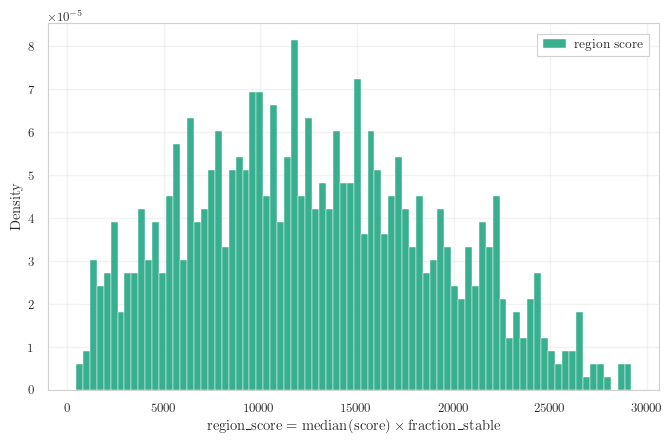

In [22]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = (
    region_summary
    .filter(pl.col("eligible") == True)
    .select("region_score")
    .to_numpy()
    .ravel()
    .astype(float)
)
rs = rs[np.isfinite(rs)]


fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"{DATASET_NAME}_region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


In [24]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", pool_A_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", pool_B_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union



STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=2,170
Pool A (anchored): clusters=1,605 | reps=1,605 | median_cluster_size=1 | max_cluster_size=324
Pool B (non-anchored): CpGs in pool=9,941
Pool B (non-anchored): clusters=8,217 | reps=8,217 | median_cluster_size=1 | max_cluster_size=1189
Union representatives: 9,822 (A=1,605, B=8,217)


[OK] Saved PDF → figures/step4/GSE69914_cluster_size_ccdf_loglog_r0.85.pdf


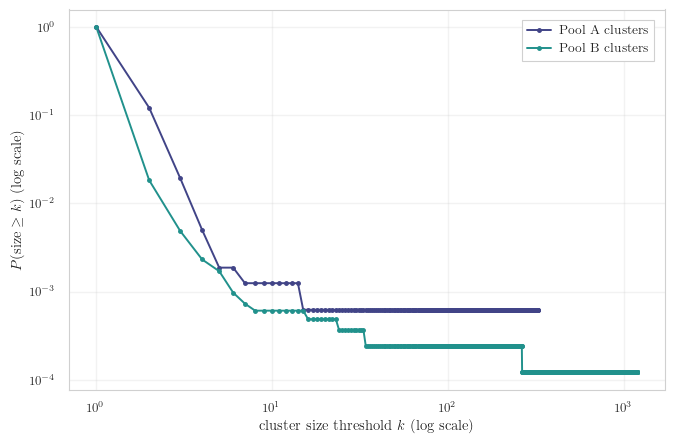

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [25]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path("figures/step4")
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE69914_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")

In [26]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 2000
CHR_MAX_FRAC = 0.20
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/humanmethylation450-15017482-v1-2-manifest/humanmethylation450_15017482_v1-2_manifest.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse



STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 9,822
Mapped reps (chr+pos available): 9,822
Stage=       strict | selected=2,000 / 2,000 | chr_budget=400 | ctx_budget=1300
Final selected after diversification: 2,000 | stage_used=strict
Top 5 chr counts: [('1', 205), ('2', 143), ('6', 138), ('8', 135), ('5', 126)]
Top 5 ctx counts: [('Island', 677), ('OpenSea', 558), ('N_Shore', 381), ('S_Shore', 263), ('N_Shelf', 61)]


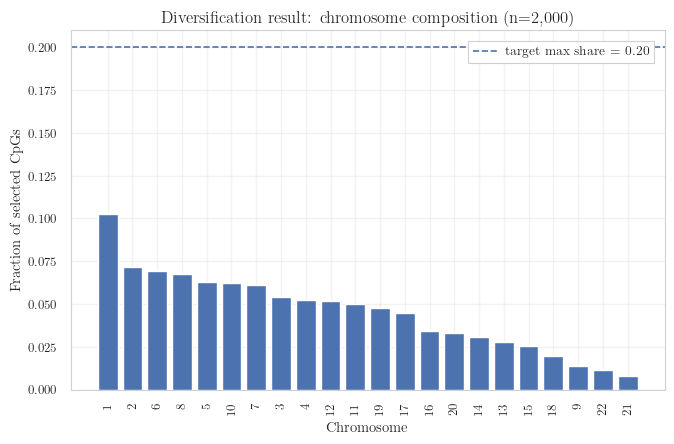

In [27]:
# =============================
# STEP 5 — PLOT: Chromosome share in final diversified set
# =============================

import numpy as np
import matplotlib.pyplot as plt

# Assumes from STEP 5:
#   selected_diverse : np.ndarray of CpGs
#   cpg_to_chr : dict CpG -> chr
#   K_TARGET, CHR_MAX_FRAC

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac)

ax.axhline(CHR_MAX_FRAC, linestyle="--", linewidth=1.2, label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=90)
ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
ax.set_title(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()
plt.show()


In [28]:
# =============================
# STEP 5 — PLOT: Spatial density constraint check (max per 500kb window)
# =============================

import numpy as np
import matplotlib.pyplot as plt

# Assumes from STEP 5:
#   selected_diverse : np.ndarray of CpGs
#   cpg_to_chr, cpg_to_pos : dicts
#   WIN_BP, MAX_PER_WIN

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    win = int(ps // WIN_BP)
    pairs.append((ch, win))

pairs = np.array(pairs, dtype=object)
if pairs.size == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

# count per (chr,win)
keys, cnt = np.unique(pairs, return_counts=True, axis=0)

fig, ax = plt.subplots()
ax.hist(cnt, bins=np.arange(1, cnt.max() + 2) - 0.5, density=True, alpha=0.90, label="CpGs per 500kb window")

ax.axvline(MAX_PER_WIN, linestyle="--", linewidth=1.2, label=rf"max allowed = {MAX_PER_WIN}")

ax.set_xlabel(f"#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")
ax.set_title("Spatial density of selected CpGs")

place_legend(ax)
fig.tight_layout()
plt.show()


TypeError: The axis argument to unique is not supported for dtype object

In [29]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 2000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs



STEP 6 — Final CpG set: K=2000 (got 2,000)


In [30]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse69914_fs_v1_2000"   # cambia come vuoi
OUTDIR = Path("./fs_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())


Saved CpGs TXT: fs_outputs/final_cpgs_K2000_gse69914_fs_v1_2000_20260218_210944.txt
Saved CpGs CSV: fs_outputs/final_cpgs_K2000_gse69914_fs_v1_2000_20260218_210944.csv
K = 2000
Example: ['cg09296001', 'cg08774368', 'cg27616661', 'cg06802522', 'cg21790626']



SVM CHECK — final FS CpGs | train/test (no leakage) + ROC
SVM_C = 1.0
SVM_MAX_ITER = 5000
RANDOM_STATE = 42
Shapes: X_train=(73, 2000) | X_test=(19, 2000)
n_features (final) = 2,000

METRICS (test):
AUC         = 0.6000
BAcc        = 0.5278
Precision   = 0.5000
Recall      = 0.5556
F1-score    = 0.5263
PR-AUC      = 0.5783
Specificity = 0.5000
MCC         = 0.0556

Confusion matrix [labels 0,1]:
[[5 5]
 [4 5]]

Classification report:
              precision    recall  f1-score   support

           0     0.5556    0.5000    0.5263        10
           1     0.5000    0.5556    0.5263         9

    accuracy                         0.5263        19
   macro avg     0.5278    0.5278    0.5263        19
weighted avg     0.5292    0.5263    0.5263        19


ROC — Linear SVM on final FS CpGs (K=2,000) | dataset=GSE69914
Saved plot to: plots_outputs/GSE69914_svmcheck_ROC_finalFS.pdf


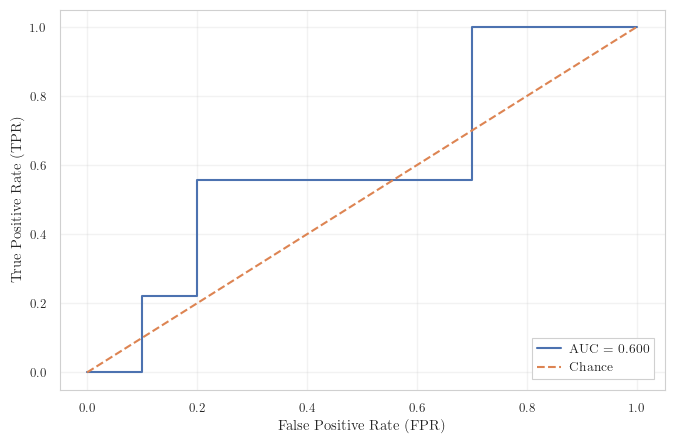

In [31]:
# =============================
# SVM CHECK — train/test on final FS CpGs + ROC plot (thesis style)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, classification_report,
    average_precision_score, matthews_corrcoef, roc_curve
)

print("\n" + "=" * 90)
print("SVM CHECK — final FS CpGs | train/test (no leakage) + ROC")
print("=" * 90)

# -----------------------------
# REQUIRED INPUTS (must exist)
# -----------------------------
#   M_train, M_test               : post-Edgar + beta->M + (optional) variance filter
#   y_train, y_test
#   cpg_cols_current              : columns aligned to M_train/M_test
#   final_cpgs                    : final selected CpGs (e.g., K=5000) from your FS pipeline
#   SVM_C, SVM_MAX_ITER, RANDOM_STATE
#   apply_thesis_style, place_legend
#
# Optional:
#   DATASET_NAME (string) e.g. "GSE225845" for saving plots

DATASET_NAME = globals().get("DATASET_NAME", "GSE69914")  # set explicitly if you want
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Default hyperparameters (if not already defined)
# -----------------------------
SVM_C = globals().get("SVM_C", 1.0)
SVM_MAX_ITER = globals().get("SVM_MAX_ITER", 5000)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

print(f"SVM_C = {SVM_C}")
print(f"SVM_MAX_ITER = {SVM_MAX_ITER}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

SVM_C = 0.5   # più regolarizzazione → meno overfitting
SVM_MAX_ITER = 10000
RANDOM_STATE = 42


# -----------------------------
# 1) Build matrices on final CpGs (aligned with current M space)
# -----------------------------
if "M_train" not in globals() or "M_test" not in globals():
    raise NameError("Missing M_train/M_test. Use the matrices produced by STEP 2 (post-Edgar + M-transform).")

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

final_cpgs = np.array(final_cpgs, dtype=object)
jj = np.array([col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int)

if jj.size == 0:
    raise RuntimeError("No final_cpgs found in cpg_cols_current. Check alignment / filtering masks.")

if jj.size != final_cpgs.size:
    missing = [c for c in final_cpgs.tolist() if c not in col_to_j]
    print(f"WARNING: {len(missing)} CpGs missing from current columns. Using {jj.size}/{final_cpgs.size}.")
    final_cpgs = np.array([c for c in final_cpgs.tolist() if c in col_to_j], dtype=object)

X_train = M_train[:, jj].astype(np.float32, copy=False)
X_test  = M_test[:,  jj].astype(np.float32, copy=False)

print(f"Shapes: X_train={X_train.shape} | X_test={X_test.shape}")
print(f"n_features (final) = {X_train.shape[1]:,}")

# -----------------------------
# 2) Linear SVM on M
# -----------------------------
svm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", LinearSVC(C=SVM_C, class_weight="balanced", max_iter=SVM_MAX_ITER, random_state=RANDOM_STATE)),
])

svm.fit(X_train, y_train)

score = svm.decision_function(X_test)
pred  = svm.predict(X_test)

auc  = roc_auc_score(y_test, score)
bacc = balanced_accuracy_score(y_test, pred)
cm   = confusion_matrix(y_test, pred, labels=[0, 1])

precision = precision_score(y_test, pred, zero_division=0)
recall    = recall_score(y_test, pred, zero_division=0)
f1        = f1_score(y_test, pred, zero_division=0)
pr_auc    = average_precision_score(y_test, score)
mcc       = matthews_corrcoef(y_test, pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp + 1e-12)

print("\nMETRICS (test):")
print(f"AUC         = {auc:.4f}")
print(f"BAcc        = {bacc:.4f}")
print(f"Precision   = {precision:.4f}")
print(f"Recall      = {recall:.4f}")
print(f"F1-score    = {f1:.4f}")
print(f"PR-AUC      = {pr_auc:.4f}")
print(f"Specificity = {specificity:.4f}")
print(f"MCC         = {mcc:.4f}")

print("\nConfusion matrix [labels 0,1]:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, pred, digits=4, zero_division=0))

# -----------------------------
# 3) ROC plot (thesis style) + SAVE PDF
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, score)

apply_thesis_style(use_tex=True, legend_position="lower right", legend_outside=False)
fig_roc, ax = plt.subplots(figsize=(6.8, 4.5))

ax.plot(fpr, tpr, label=rf"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# no plot title (print to screen instead)
print(f"\nROC — Linear SVM on final FS CpGs (K={X_train.shape[1]:,}) | dataset={DATASET_NAME}")

place_legend(ax)
fig_roc.tight_layout()

pdf_path = OUTDIR / f"{DATASET_NAME}_svmcheck_ROC_finalFS.pdf"
fig_roc.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

# Outputs you may reuse later:
#   svm, fig_roc, score, pred, (auc, bacc, precision, recall, f1, pr_auc, specificity, mcc), cm



FIG — PCA boundary with calibrated probability (train-only fit)

Dataset: GSE69914
SVM_C=0.5 | SVM_MAX_ITER=10000 | RANDOM_STATE=42
Saved plot to: plots_outputs/GSE69914_boundary_pca_prob_calibrated.pdf


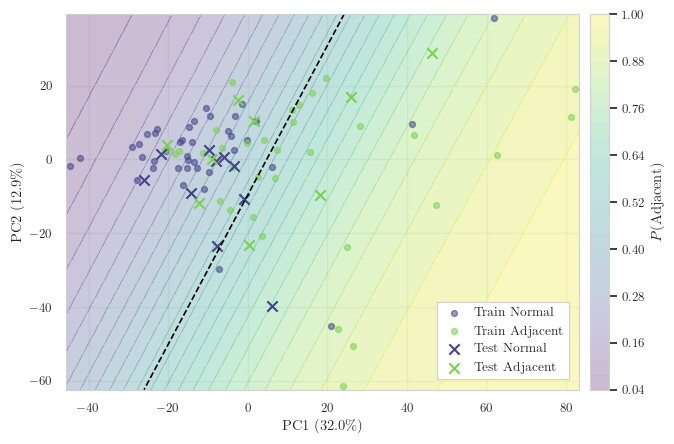

SVM boundary in PCA space | AUC=0.600


In [32]:
# =========================
# FIG — Boundary in PCA space + colorbar (calibrated probability)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV

# -----------------------------
# CHECK REQUIRED MATRICES
# -----------------------------
if "X_train" not in globals() or "X_test" not in globals():
    raise RuntimeError("X_train / X_test not found. Run the SVM CHECK cell first.")

# -----------------------------
# CONFIG
# -----------------------------
DATASET_NAME = "GSE69914"
OUTDIR = Path("./plots_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

SVM_C = 0.5
SVM_MAX_ITER = 10000
RANDOM_STATE = 42

print("\nFIG — PCA boundary with calibrated probability (train-only fit)\n")
print(f"Dataset: {DATASET_NAME}")
print(f"SVM_C={SVM_C} | SVM_MAX_ITER={SVM_MAX_ITER} | RANDOM_STATE={RANDOM_STATE}")

# -----------------------------
# 1) Fit Linear SVM (train-only)
# -----------------------------
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        max_iter=SVM_MAX_ITER,
        random_state=RANDOM_STATE
    )),
])

svm_pipe.fit(X_train, y_train)

# -----------------------------
# 2) Calibrate (train-only)
# -----------------------------
cal = CalibratedClassifierCV(estimator=svm_pipe, method="sigmoid", cv=3)
cal.fit(X_train, y_train)

# -----------------------------
# 3) PCA (fit ONLY on train)
# -----------------------------
pca_scaler = StandardScaler()
Xtr_std = pca_scaler.fit_transform(X_train)
Xte_std = pca_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Ztr = pca.fit_transform(Xtr_std)
Zte = pca.transform(Xte_std)

ve = pca.explained_variance_ratio_

# -----------------------------
# 4) Grid in PCA space
# -----------------------------
Z_all = np.vstack([Ztr, Zte])
x_min, x_max = Z_all[:,0].min()-1, Z_all[:,0].max()+1
y_min, y_max = Z_all[:,1].min()-1, Z_all[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 240),
    np.linspace(y_min, y_max, 240)
)

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_std = pca.inverse_transform(grid_pca)
grid_orig = pca_scaler.inverse_transform(grid_std)

zz = cal.predict_proba(grid_orig)[:,1].reshape(xx.shape)

# -----------------------------
# 5) Plot
# -----------------------------
apply_thesis_style(use_tex=True, legend_position="lower right")

fig, ax = plt.subplots(figsize=(6.8, 4.5))

cf = ax.contourf(xx, yy, zz, levels=25, cmap="viridis", alpha=0.28)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linestyles="--", linewidths=1.2)

c0 = plt.cm.viridis(0.20)
c1 = plt.cm.viridis(0.80)

ax.scatter(Ztr[y_train==0,0], Ztr[y_train==0,1],
           s=18, alpha=0.55, c=[c0], label="Train Normal")

ax.scatter(Ztr[y_train==1,0], Ztr[y_train==1,1],
           s=18, alpha=0.55, c=[c1], label="Train Adjacent")

ax.scatter(Zte[y_test==0,0], Zte[y_test==0,1],
           s=55, marker="x", c=[c0], label="Test Normal")

ax.scatter(Zte[y_test==1,0], Zte[y_test==1,1],
           s=55, marker="x", c=[c1], label="Test Adjacent")

ax.set_xlabel(rf"$\mathrm{{PC1}}\ ({ve[0]*100:.1f}\%)$")
ax.set_ylabel(rf"$\mathrm{{PC2}}\ ({ve[1]*100:.1f}\%)$")

cbar = fig.colorbar(cf, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label(r"$P(\mathrm{Adjacent})$")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE
# -----------------------------
pdf_path = OUTDIR / f"{DATASET_NAME}_boundary_pca_prob_calibrated.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"SVM boundary in PCA space | AUC={auc:.3f}")


In [33]:
# =============================
# FEATURE IMPORTANCE — Linear SVM
# =============================

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

print("\n" + "="*90)
print("FEATURE IMPORTANCE — Linear SVM coefficients")
print("="*90)

# Extract coefficients (after scaling inside pipeline)
coef = svm.named_steps["svm"].coef_.ravel()   # shape (n_features,)

feature_names = np.array(final_cpgs, dtype=object)

# Safety check
assert coef.size == feature_names.size, "Mismatch between coefficients and feature names"

abs_coef = np.abs(coef)

# Non-zero coefficients
nonzero_mask = abs_coef > 1e-12
n_nonzero = int(nonzero_mask.sum())

print(f"Total features: {coef.size:,}")
print(f"Non-zero coefficients: {n_nonzero:,}")
print(f"Sparsity: {100*(1 - n_nonzero/coef.size):.2f}%")

# Build importance table
imp_df = pl.DataFrame({
    "cpg": feature_names,
    "coef": coef,
    "abs_coef": abs_coef
}).sort("abs_coef", descending=True)

# Save
OUTDIR = Path("./feature_importance")
OUTDIR.mkdir(parents=True, exist_ok=True)

csv_path = OUTDIR / f"{DATASET}_svm_feature_importance.csv"
imp_df.write_csv(csv_path)

print(f"Saved feature importance → {csv_path}")

# Show top 10 positive / negative
top_pos = imp_df.filter(pl.col("coef") > 0).head(10)
top_neg = imp_df.filter(pl.col("coef") < 0).head(10)

print("\nTop positive coefficients:")
print(top_pos)

print("\nTop negative coefficients:")
print(top_neg)



FEATURE IMPORTANCE — Linear SVM coefficients
Total features: 2,000
Non-zero coefficients: 2,000
Sparsity: 0.00%
Saved feature importance → feature_importance/GSE69914_svm_feature_importance.csv

Top positive coefficients:
shape: (10, 3)
┌────────────┬──────────┬──────────┐
│ cpg        ┆ coef     ┆ abs_coef │
│ ---        ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ cg01407748 ┆ 0.022965 ┆ 0.022965 │
│ cg11714341 ┆ 0.021994 ┆ 0.021994 │
│ cg14515517 ┆ 0.021883 ┆ 0.021883 │
│ cg00693710 ┆ 0.021263 ┆ 0.021263 │
│ cg21576300 ┆ 0.02036  ┆ 0.02036  │
│ cg00351152 ┆ 0.02004  ┆ 0.02004  │
│ cg14047540 ┆ 0.019862 ┆ 0.019862 │
│ cg24494617 ┆ 0.017462 ┆ 0.017462 │
│ cg10658240 ┆ 0.017356 ┆ 0.017356 │
│ cg19262377 ┆ 0.017127 ┆ 0.017127 │
└────────────┴──────────┴──────────┘

Top negative coefficients:
shape: (10, 3)
┌────────────┬───────────┬──────────┐
│ cpg        ┆ coef      ┆ abs_coef │
│ ---        ┆ ---       ┆ ---      │
│ str        

In [45]:
# =============================
# KNAPSACK / MILP selection (no Gurobi): PuLP(CBC) if available, else greedy
# =============================

import numpy as np

def solve_cpg_selection_no_gurobi(
    final_cpgs,
    coef,
    pool_A_cpgs,
    cpg_to_chr,
    K=50,
    K_A_min=20,
    chr_max=8,
    K_pos_min=None,
    K_neg_min=None,
    conflict_edges=None,   # list of (cpg_i, cpg_j), optional
    time_limit_sec=60,
    verbose=True,
):
    final_cpgs = np.array(final_cpgs, dtype=object)
    coef = np.asarray(coef, dtype=float).ravel()
    assert final_cpgs.size == coef.size, "final_cpgs and coef must be aligned"

    v = np.abs(coef)
    poolA = set(np.array(pool_A_cpgs, dtype=object).tolist())

    # metadata vectors
    chr_arr = np.array([cpg_to_chr.get(c, "") for c in final_cpgs], dtype=object)
    sign_arr = np.sign(coef).astype(int)

    # index maps
    idx_of = {c: i for i, c in enumerate(final_cpgs.tolist())}

    # build conflict index pairs if provided
    conflict_pairs = []
    if conflict_edges is not None:
        for a, b in conflict_edges:
            if a in idx_of and b in idx_of:
                ia, ib = idx_of[a], idx_of[b]
                if ia != ib:
                    conflict_pairs.append((ia, ib))

    # ---------- Try MILP (PuLP + CBC) ----------
    try:
        import pulp

        if verbose:
            print("[MILP] Using PuLP + CBC (no Gurobi).")

        prob = pulp.LpProblem("CpG_Knapsack", pulp.LpMaximize)
        x = [pulp.LpVariable(f"x_{i}", lowBound=0, upBound=1, cat="Binary") for i in range(final_cpgs.size)]

        # objective: maximize sum v_i x_i
        prob += pulp.lpSum(v[i] * x[i] for i in range(final_cpgs.size))

        # (C1) cardinality
        prob += pulp.lpSum(x) == int(K)

        # (C2) pool A min
        A_idx = [i for i, c in enumerate(final_cpgs.tolist()) if c in poolA]
        prob += pulp.lpSum(x[i] for i in A_idx) >= int(K_A_min)

        # (C3) chromosome caps
        uniq_chr = [c for c in np.unique(chr_arr) if c != ""]
        for ch in uniq_chr:
            idx_ch = np.where(chr_arr == ch)[0].tolist()
            prob += pulp.lpSum(x[i] for i in idx_ch) <= int(chr_max)

        # (C5) sign caps (optional)
        if K_pos_min is not None:
            idx_pos = np.where(sign_arr > 0)[0].tolist()
            prob += pulp.lpSum(x[i] for i in idx_pos) >= int(K_pos_min)
        if K_neg_min is not None:
            idx_neg = np.where(sign_arr < 0)[0].tolist()
            prob += pulp.lpSum(x[i] for i in idx_neg) >= int(K_neg_min)

        # (C4) conflicts (optional)
        if conflict_pairs:
            for ia, ib in conflict_pairs:
                prob += x[ia] + x[ib] <= 1

        # solve with CBC
        solver = pulp.PULP_CBC_CMD(msg=1 if verbose else 0, timeLimit=int(time_limit_sec))
        status = prob.solve(solver)

        if pulp.LpStatus[status] not in ("Optimal", "Not Solved", "Infeasible", "Undefined", "Unbounded"):
            # defensive; normally not needed
            pass

        if pulp.LpStatus[status] in ("Optimal", "Not Solved"):
            x_val = np.array([pulp.value(var) for var in x], dtype=float)
            sel_idx = np.where(x_val > 0.5)[0]
            selected = final_cpgs[sel_idx].tolist()

            if verbose:
                obj = float(np.sum(v[sel_idx]))
                print(f"[MILP] Status={pulp.LpStatus[status]} | selected={len(selected)} | objective(sum|w|)={obj:.6f}")

            # sanity check feasibility (basic)
            if len(selected) != K:
                raise RuntimeError("MILP returned selection with wrong cardinality.")

            return {
                "method": "MILP_PuLP_CBC",
                "selected": selected,
                "selected_idx": sel_idx,
                "objective": float(np.sum(v[sel_idx])),
            }

        if verbose:
            print(f"[MILP] Status={pulp.LpStatus[status]} → fallback to greedy.")

    except Exception as e:
        if verbose:
            print(f"[MILP] PuLP/CBC not available or failed ({type(e).__name__}: {e}) → fallback to greedy.")

    # ---------- Fallback: Greedy with constraints ----------
    if verbose:
        print("[GREEDY] Running constrained greedy (no solver).")

    order = np.argsort(-v, kind="mergesort")  # descending |w|
    selected_idx = []

    # trackers
    count_A = 0
    chr_count = {}
    count_pos = 0
    count_neg = 0

    # fast conflict check
    conflict_adj = None
    if conflict_pairs:
        conflict_adj = [set() for _ in range(final_cpgs.size)]
        for ia, ib in conflict_pairs:
            conflict_adj[ia].add(ib)
            conflict_adj[ib].add(ia)

    def violates(i):
        nonlocal count_A, chr_count, count_pos, count_neg

        cpg = final_cpgs[i]
        ch = chr_arr[i]
        sg = sign_arr[i]

        # chr cap
        if ch != "":
            if chr_count.get(ch, 0) >= chr_max:
                return True

        # conflicts
        if conflict_adj is not None:
            si = set(selected_idx)
            if any((j in si) for j in conflict_adj[i]):
                return True

        return False

    # Phase 1: ensure Pool A quota (and optional sign quotas) by prioritizing them
    # Strategy: iterate ordered list, but only accept if it helps satisfy missing quotas first.
    def need_A():
        return count_A < K_A_min

    def need_pos():
        return (K_pos_min is not None) and (count_pos < K_pos_min)

    def need_neg():
        return (K_neg_min is not None) and (count_neg < K_neg_min)

    for i in order:
        if len(selected_idx) >= K:
            break
        if violates(i):
            continue

        cpg = final_cpgs[i]
        is_A = (cpg in poolA)
        sg = sign_arr[i]

        # if we still need Pool A, only take A until satisfied
        if need_A() and not is_A:
            continue
        # if we still need sign quotas, enforce them softly
        if need_pos() and sg <= 0:
            continue
        if need_neg() and sg >= 0:
            continue

        # accept
        selected_idx.append(int(i))
        if is_A:
            count_A += 1
        if chr_arr[i] != "":
            chr_count[chr_arr[i]] = chr_count.get(chr_arr[i], 0) + 1
        if sg > 0:
            count_pos += 1
        elif sg < 0:
            count_neg += 1

    # Phase 2: fill remaining slots without quota restrictions (just hard constraints)
    for i in order:
        if len(selected_idx) >= K:
            break
        if i in selected_idx:
            continue
        if violates(i):
            continue

        # accept
        selected_idx.append(int(i))
        cpg = final_cpgs[i]
        if cpg in poolA:
            count_A += 1
        if chr_arr[i] != "":
            chr_count[chr_arr[i]] = chr_count.get(chr_arr[i], 0) + 1
        sg = sign_arr[i]
        if sg > 0:
            count_pos += 1
        elif sg < 0:
            count_neg += 1

    selected_idx = np.array(selected_idx, dtype=int)
    selected = final_cpgs[selected_idx].tolist()

    if verbose:
        print(f"[GREEDY] selected={len(selected)} | PoolA={count_A} | pos={count_pos} | neg={count_neg} | objective(sum|w|)={float(np.sum(v[selected_idx])):.6f}")

    if len(selected) != K:
        raise RuntimeError(
            f"Greedy could not fill K={K}. "
            f"Try relaxing constraints: lower K_A_min, increase chr_max, remove conflicts, or remove sign constraints."
        )

    return {
        "method": "GREEDY",
        "selected": selected,
        "selected_idx": selected_idx,
        "objective": float(np.sum(v[selected_idx])),
        "count_A": int(count_A),
        "count_pos": int(count_pos),
        "count_neg": int(count_neg),
        "chr_count": dict(chr_count),
    }


In [46]:
result8 = solve_cpg_selection_no_gurobi(
    final_cpgs=final_cpgs,
    coef=coef,
    pool_A_cpgs=pool_A_cpgs,
    cpg_to_chr=cpg_to_chr,
    K=50,
    K_A_min=20,
    chr_max=8,
    conflict_edges=None,
    verbose=True
)


selected_50 = result["selected"]
print(result["method"], len(selected_50))
print(selected_50)


[MILP] PuLP/CBC not available or failed (ModuleNotFoundError: No module named 'pulp') → fallback to greedy.
[GREEDY] Running constrained greedy (no solver).
[GREEDY] selected=50 | PoolA=30 | pos=32 | neg=18 | objective(sum|w|)=0.543902
GREEDY 50
['cg19262377', 'cg14200364', 'cg23503501', 'cg00308159', 'cg04991337', 'cg18706028', 'cg16929496', 'cg10363337', 'cg08774368', 'cg17805540', 'cg22210157', 'cg24154951', 'cg18566594', 'cg15825916', 'cg02867079', 'cg13455704', 'cg23918580', 'cg00174901', 'cg10623840', 'cg18206027', 'cg06680906', 'cg23652785', 'cg25085038', 'cg19599045', 'cg06711078', 'cg19801062', 'cg03475665', 'cg06971096', 'cg15167956', 'cg08164484', 'cg17440044', 'cg05746024', 'cg24182581', 'cg04462627', 'cg16620382', 'cg01816714', 'cg00182053', 'cg05230567', 'cg18140645', 'cg23994303', 'cg15846718', 'cg09122588', 'cg18264687', 'cg02505749', 'cg23230584', 'cg00318436', 'cg12634932', 'cg17054759', 'cg17296482', 'cg00888801']


In [47]:
sel = np.array(selected_50, dtype=object)

nA = int(np.isin(sel, np.array(pool_A_cpgs, dtype=object)).sum())
print("PoolA selected:", nA)

ch = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
uniq, cnt = np.unique(ch[ch != ""], return_counts=True)
mx = cnt.max() if cnt.size else 0
print("Max per chromosome:", int(mx))

# mostra eventuali cromosomi a soglia
for u, c in sorted(zip(uniq.tolist(), cnt.tolist()), key=lambda x: -x[1])[:10]:
    print(u, c)


PoolA selected: 30
Max per chromosome: 4
1 4
13 4
14 4
19 4
3 4
12 3
22 3
5 3
6 3
7 3


In [48]:
v = np.abs(np.asarray(coef, float).ravel())
order = np.argsort(-v, kind="mergesort")
top50_idx = order[:50]
top50_obj = float(v[top50_idx].sum())

greedy_obj = result["objective"]

print("Objective top-50 (no constraints):", top50_obj)
print("Objective greedy (constraints):   ", greedy_obj)
print("Relative loss:", (top50_obj - greedy_obj) / max(top50_obj, 1e-12))


Objective top-50 (no constraints): 0.817460384714126
Objective greedy (constraints):    0.5414543171969098
Relative loss: 0.3376384625827932


In [75]:
# ============================================================
# KNAPSACK / MILP selection (no Gurobi): PuLP(CBC) if available, else GREEDY (quota-enforcing)
# Goal: K=50, balanced sign (Normal vs Adj proxy), more from pool_A than pool_B
# ============================================================

import numpy as np

def solve_cpg_selection_no_gurobi(
    final_cpgs,
    coef,
    pool_A_cpgs,
    pool_B_cpgs=None,
    cpg_to_chr=None,
    K=50,
    K_A_min=35,
    K_B_max=15,
    chr_max=8,
    balance=True,
    K_pos_min=None,
    K_neg_min=None,
    conflict_edges=None,   # list of (cpg_i, cpg_j), optional
    time_limit_sec=60,
    verbose=True,
):
    final_cpgs = np.array(final_cpgs, dtype=object)
    coef = np.asarray(coef, dtype=float).ravel()
    assert final_cpgs.size == coef.size, "final_cpgs and coef must be aligned"

    v = np.abs(coef)
    poolA = set(np.array(pool_A_cpgs, dtype=object).tolist())
    poolB = set(np.array(pool_B_cpgs, dtype=object).tolist()) if pool_B_cpgs is not None else set()

    # metadata vectors
    chr_arr = (
        np.array([cpg_to_chr.get(c, "") for c in final_cpgs], dtype=object)
        if cpg_to_chr is not None
        else np.array([""] * final_cpgs.size, dtype=object)
    )
    sign_arr = np.sign(coef).astype(int)  # -1, 0, +1

    # auto-balance (proxy Normal vs Adj via sign of coef)
    if balance and (K_pos_min is None) and (K_neg_min is None):
        K_pos_min = K // 2
        K_neg_min = K - K_pos_min

    # --- quick feasibility sanity checks (necessary conditions) ---
    nA = int(np.sum([c in poolA for c in final_cpgs.tolist()]))
    nB = int(np.sum([c in poolB for c in final_cpgs.tolist()])) if poolB else 0
    npos = int(np.sum(sign_arr > 0))
    nneg = int(np.sum(sign_arr < 0))

    if verbose:
        print(f"[CHECK] N={final_cpgs.size} | nA={nA} | nB={nB} | npos={npos} | nneg={nneg}")
        print(f"[CHECK] targets: K={K} | K_A_min={K_A_min} | K_B_max={K_B_max} | chr_max={chr_max} | K_pos_min={K_pos_min} | K_neg_min={K_neg_min}")

    if nA < K_A_min:
        raise ValueError(f"Infeasible: nA={nA} < K_A_min={K_A_min}. Relax K_A_min or enlarge pool_A.")
    if poolB and (K_B_max is not None) and (K_B_max > nB):
        raise ValueError(f"Infeasible: K_B_max={K_B_max} > nB={nB}. Relax K_B_max or enlarge pool_B.")
    if (K_pos_min is not None) and (npos < K_pos_min):
        raise ValueError(f"Infeasible: npos={npos} < K_pos_min={K_pos_min}. Relax balance or K_pos_min.")
    if (K_neg_min is not None) and (nneg < K_neg_min):
        raise ValueError(f"Infeasible: nneg={nneg} < K_neg_min={K_neg_min}. Relax balance or K_neg_min.")
    if (K_pos_min is not None) and (K_neg_min is not None) and (K_pos_min + K_neg_min > K):
        raise ValueError("Infeasible: K_pos_min + K_neg_min > K.")

    # index maps
    idx_of = {c: i for i, c in enumerate(final_cpgs.tolist())}

    # build conflict index pairs if provided
    conflict_pairs = []
    if conflict_edges is not None:
        for a, b in conflict_edges:
            if a in idx_of and b in idx_of:
                ia, ib = idx_of[a], idx_of[b]
                if ia != ib:
                    conflict_pairs.append((ia, ib))

    # ---------- Try MILP (PuLP + CBC) ----------
    try:
        import pulp
        if verbose:
            print("[MILP] Using PuLP + CBC (no Gurobi).")

        prob = pulp.LpProblem("CpG_Knapsack", pulp.LpMaximize)
        x = [pulp.LpVariable(f"x_{i}", lowBound=0, upBound=1, cat="Binary") for i in range(final_cpgs.size)]

        # objective: maximize sum |w_i| x_i
        prob += pulp.lpSum(v[i] * x[i] for i in range(final_cpgs.size))

        # (C1) cardinality
        prob += pulp.lpSum(x) == int(K)

        # (C2) pool A min
        A_idx = [i for i, c in enumerate(final_cpgs.tolist()) if c in poolA]
        prob += pulp.lpSum(x[i] for i in A_idx) >= int(K_A_min)

        # (C2b) pool B max (optional)
        if poolB and (K_B_max is not None):
            B_idx = [i for i, c in enumerate(final_cpgs.tolist()) if c in poolB]
            prob += pulp.lpSum(x[i] for i in B_idx) <= int(K_B_max)

        # (C3) chromosome caps
        if cpg_to_chr is not None:
            uniq_chr = [c for c in np.unique(chr_arr) if c != ""]
            for ch in uniq_chr:
                idx_ch = np.where(chr_arr == ch)[0].tolist()
                prob += pulp.lpSum(x[i] for i in idx_ch) <= int(chr_max)

        # (C4) conflicts (optional)
        if conflict_pairs:
            for ia, ib in conflict_pairs:
                prob += x[ia] + x[ib] <= 1

        # (C5) sign balance (optional)
        if K_pos_min is not None:
            idx_pos = np.where(sign_arr > 0)[0].tolist()
            prob += pulp.lpSum(x[i] for i in idx_pos) >= int(K_pos_min)
        if K_neg_min is not None:
            idx_neg = np.where(sign_arr < 0)[0].tolist()
            prob += pulp.lpSum(x[i] for i in idx_neg) >= int(K_neg_min)

        solver = pulp.PULP_CBC_CMD(msg=1 if verbose else 0, timeLimit=int(time_limit_sec))
        status = prob.solve(solver)
        status_str = pulp.LpStatus.get(status, str(status))

        if status_str in ("Optimal", "Not Solved"):
            x_val = np.array([pulp.value(var) for var in x], dtype=float)
            sel_idx = np.where(x_val > 0.5)[0]
            selected = final_cpgs[sel_idx].tolist()

            if len(selected) != K:
                raise RuntimeError("MILP returned selection with wrong cardinality.")

            if verbose:
                obj = float(np.sum(v[sel_idx]))
                count_A = int(np.sum([c in poolA for c in selected]))
                count_B = int(np.sum([c in poolB for c in selected])) if poolB else 0
                count_pos = int(np.sum(np.sign(coef[sel_idx]) > 0))
                count_neg = int(np.sum(np.sign(coef[sel_idx]) < 0))
                print(f"[MILP] Status={status_str} | selected={len(selected)} | obj(sum|w|)={obj:.6f} | A={count_A} | B={count_B} | pos={count_pos} | neg={count_neg}")

            return {
                "method": "MILP_PuLP_CBC",
                "selected": selected,
                "selected_idx": sel_idx,
                "objective": float(np.sum(v[sel_idx])),
            }

        if verbose:
            print(f"[MILP] Status={status_str} → fallback to greedy.")

    except Exception as e:
        if verbose:
            print(f"[MILP] PuLP/CBC not available or failed ({type(e).__name__}: {e}) → fallback to greedy.")

    # ---------- Fallback: GREEDY that ENFORCES quotas ----------
    if verbose:
        print("[GREEDY] Running quota-enforcing greedy (no solver).")

    order = np.argsort(-v, kind="mergesort")
    selected = []
    selset = set()

    count_A = 0
    count_B = 0
    count_pos = 0
    count_neg = 0
    chr_count = {}

    # conflicts adjacency
    conflict_adj = None
    if conflict_pairs:
        conflict_adj = [set() for _ in range(final_cpgs.size)]
        for ia, ib in conflict_pairs:
            conflict_adj[ia].add(ib)
            conflict_adj[ib].add(ia)

    def violates(i):
        ch = chr_arr[i]
        if cpg_to_chr is not None and ch != "" and chr_count.get(ch, 0) >= chr_max:
            return True
        if poolB and (K_B_max is not None) and (final_cpgs[i] in poolB) and (count_B >= K_B_max):
            return True
        if conflict_adj is not None:
            for j in conflict_adj[i]:
                if j in selset:
                    return True
        return False

    def add(i):
        nonlocal count_A, count_B, count_pos, count_neg
        selected.append(int(i))
        selset.add(int(i))

        cpg = final_cpgs[i]
        if cpg in poolA:
            count_A += 1
        if cpg in poolB:
            count_B += 1

        if cpg_to_chr is not None and chr_arr[i] != "":
            chr_count[chr_arr[i]] = chr_count.get(chr_arr[i], 0) + 1

        sg = sign_arr[i]
        if sg > 0:
            count_pos += 1
        elif sg < 0:
            count_neg += 1

    def take_best(predicate, target_count):
        taken = 0
        for i in order:
            if len(selected) >= K:
                break
            if i in selset:
                continue
            if violates(i):
                continue
            if not predicate(i):
                continue
            add(i)
            taken += 1
            if taken >= target_count:
                break
        return taken

    # Phase 1: satisfy Pool A quota
    need_A = max(0, K_A_min - count_A)
    if need_A > 0:
        took = take_best(lambda i: (final_cpgs[i] in poolA), need_A)
        if took < need_A:
            raise RuntimeError(f"Greedy infeasible: cannot reach K_A_min={K_A_min} under current hard constraints.")

    # Phase 2: satisfy NEG quota first (your failure mode), then POS quota
    need_neg = max(0, K_neg_min - count_neg) if K_neg_min is not None else 0
    if need_neg > 0:
        took = take_best(lambda i: (sign_arr[i] < 0), need_neg)
        if took < need_neg:
            raise RuntimeError(
                f"Greedy infeasible: cannot satisfy K_neg_min={K_neg_min} under constraints "
                f"(chr_max={chr_max}, K_B_max={K_B_max}, K_A_min={K_A_min})."
            )

    need_pos = max(0, K_pos_min - count_pos) if K_pos_min is not None else 0
    if need_pos > 0:
        took = take_best(lambda i: (sign_arr[i] > 0), need_pos)
        if took < need_pos:
            raise RuntimeError(
                f"Greedy infeasible: cannot satisfy K_pos_min={K_pos_min} under constraints "
                f"(chr_max={chr_max}, K_B_max={K_B_max}, K_A_min={K_A_min})."
            )

    # Phase 3: fill remaining
    remaining = K - len(selected)
    if remaining > 0:
        take_best(lambda i: True, remaining)

    if len(selected) != K:
        raise RuntimeError(
            f"Greedy could not fill K={K} (filled {len(selected)}). "
            f"Relax constraints: increase chr_max, increase K_B_max, reduce K_A_min, relax sign quotas."
        )

    selected_idx = np.array(selected, dtype=int)
    selected_cpgs = final_cpgs[selected_idx].tolist()

    if verbose:
        obj = float(np.sum(v[selected_idx]))
        print(f"[GREEDY] selected={len(selected_cpgs)} | A={count_A} | B={count_B} | pos={count_pos} | neg={count_neg} | obj(sum|w|)={obj:.6f}")

    # final hard checks
    if count_A < K_A_min:
        raise RuntimeError(f"Greedy failed PoolA quota: A={count_A} < K_A_min={K_A_min}.")
    if poolB and (K_B_max is not None) and (count_B > K_B_max):
        raise RuntimeError(f"Greedy violated PoolB cap: B={count_B} > K_B_max={K_B_max}.")
    if (K_pos_min is not None) and (count_pos < K_pos_min):
        raise RuntimeError(f"Greedy failed pos quota: pos={count_pos} < K_pos_min={K_pos_min}.")
    if (K_neg_min is not None) and (count_neg < K_neg_min):
        raise RuntimeError(f"Greedy failed neg quota: neg={count_neg} < K_neg_min={K_neg_min}.")

    return {
        "method": "GREEDY_QUOTA",
        "selected": selected_cpgs,
        "selected_idx": selected_idx,
        "objective": float(np.sum(v[selected_idx])),
        "count_A": int(count_A),
        "count_B": int(count_B),
        "count_pos": int(count_pos),
        "count_neg": int(count_neg),
        "chr_count": dict(chr_count),
    }

# =============================
# HOW TO CALL IT
# =============================

res = solve_cpg_selection_no_gurobi(
    final_cpgs=final_cpgs,
    coef=coef,
    pool_A_cpgs=pool_A_cpgs,
    pool_B_cpgs=pool_B_cpgs,   # None if not used
    cpg_to_chr=cpg_to_chr,     # None to disable chr caps
    K=25,
    K_A_min=15,
    K_B_max=10,
    chr_max=8,
    balance=True,              # enforces ~25 pos and ~25 neg
    conflict_edges=None,
    time_limit_sec=60,
    verbose=True,
)

selected_cpgs = res["selected"]
selected_idx  = res["selected_idx"]

print("\n[RESULT] method:", res["method"])
print("[RESULT] n_selected:", len(selected_cpgs))
print("[RESULT] A,B,pos,neg:", res["count_A"], res["count_B"], res["count_pos"], res["count_neg"])
print("[RESULT] first 10 CpGs:", selected_cpgs)


[CHECK] N=2000 | nA=677 | nB=1323 | npos=1040 | nneg=960
[CHECK] targets: K=25 | K_A_min=15 | K_B_max=10 | chr_max=8 | K_pos_min=12 | K_neg_min=13
[MILP] PuLP/CBC not available or failed (ModuleNotFoundError: No module named 'pulp') → fallback to greedy.
[GREEDY] Running quota-enforcing greedy (no solver).
[GREEDY] selected=25 | A=15 | B=10 | pos=12 | neg=13 | obj(sum|w|)=0.383088

[RESULT] method: GREEDY_QUOTA
[RESULT] n_selected: 25
[RESULT] A,B,pos,neg: 15 10 12 13
[RESULT] first 10 CpGs: ['cg19262377', 'cg14200364', 'cg23503501', 'cg00308159', 'cg04991337', 'cg18706028', 'cg16929496', 'cg10363337', 'cg08774368', 'cg17805540', 'cg22210157', 'cg24154951', 'cg18566594', 'cg15825916', 'cg02867079', 'cg07977927', 'cg20320494', 'cg12129209', 'cg11336382', 'cg06392241', 'cg13779451', 'cg13088568', 'cg26764761', 'cg14188774', 'cg10859930']


In [76]:
sel = np.array(selected_cpgs, dtype=object)

nA = int(np.isin(sel, np.array(pool_A_cpgs, dtype=object)).sum())
print("PoolA selected:", nA)

ch = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
uniq, cnt = np.unique(ch[ch != ""], return_counts=True)
mx = cnt.max() if cnt.size else 0
print("Max per chromosome:", int(mx))

# mostra eventuali cromosomi a soglia
for u, c in sorted(zip(uniq.tolist(), cnt.tolist()), key=lambda x: -x[1])[:10]:
    print(u, c)


PoolA selected: 15
Max per chromosome: 3
2 3
3 3
1 2
12 2
14 2
19 2
22 2
4 2
7 2
8 2


In [77]:
v = np.abs(np.asarray(coef, float).ravel())
order = np.argsort(-v, kind="mergesort")

top50_idx = order[:50]
top50_obj = float(v[top50_idx].sum())

greedy_obj = float(res["objective"])  # from the last run (res dict)

print("Objective top-50 (no constraints):", top50_obj)
print("Objective selected (constraints):  ", greedy_obj)
print("Relative loss:", (top50_obj - greedy_obj) / max(top50_obj, 1e-12))


Objective top-50 (no constraints): 0.817460384714126
Objective selected (constraints):   0.3830877280243689
Relative loss: 0.531368448933047


[USING] train: X_tr shape=(59, 25), y_tr shape=(59,)
[USING] test : X_test shape=(19, 25), y_test shape=(19,)
[USING] CpGs : selected_cpgs


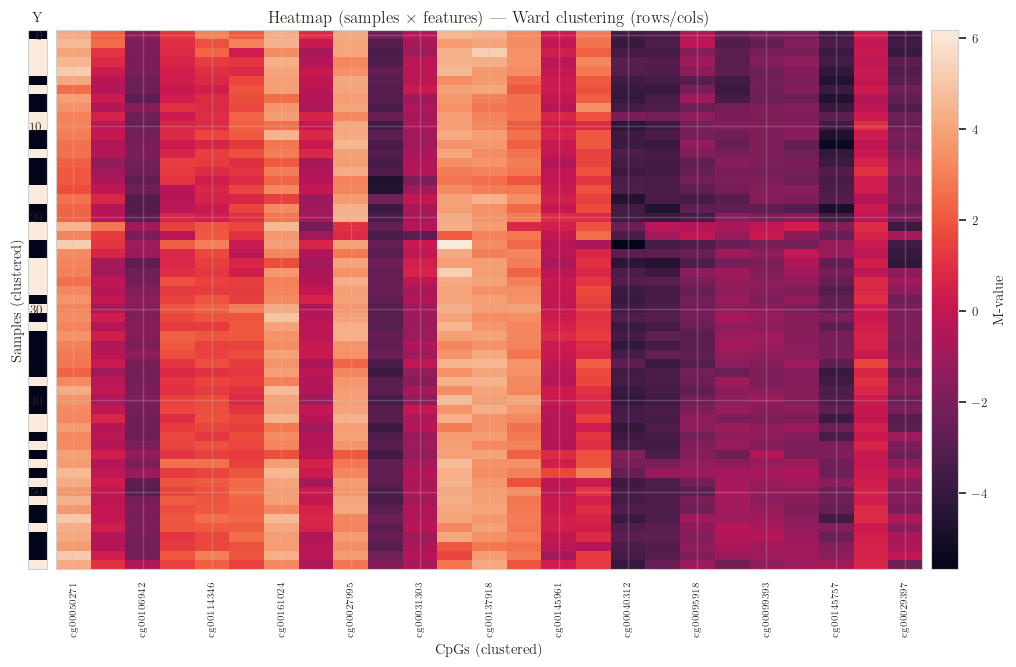

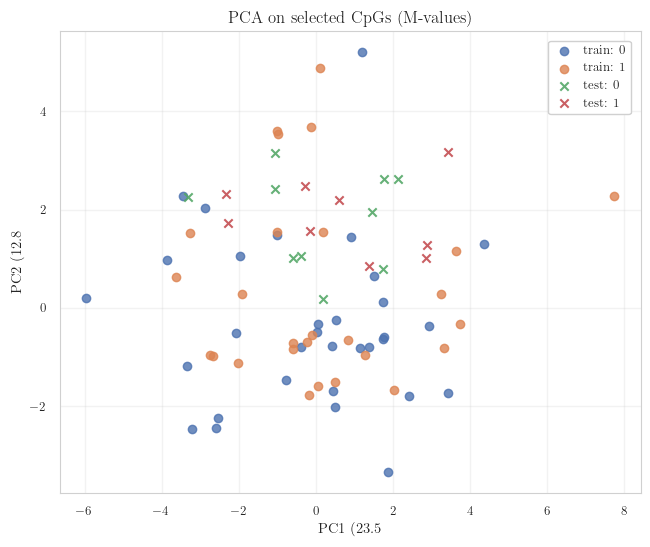

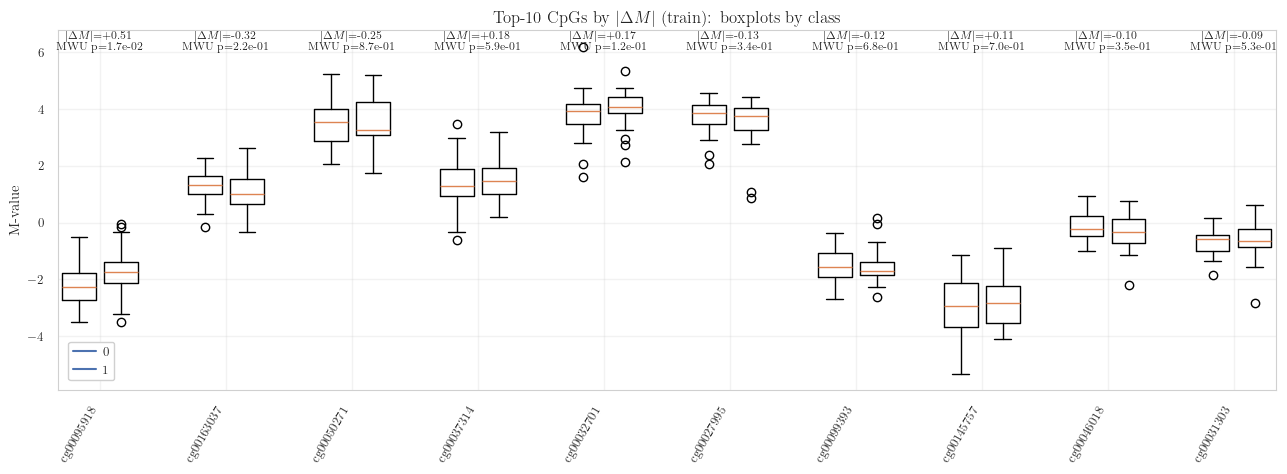

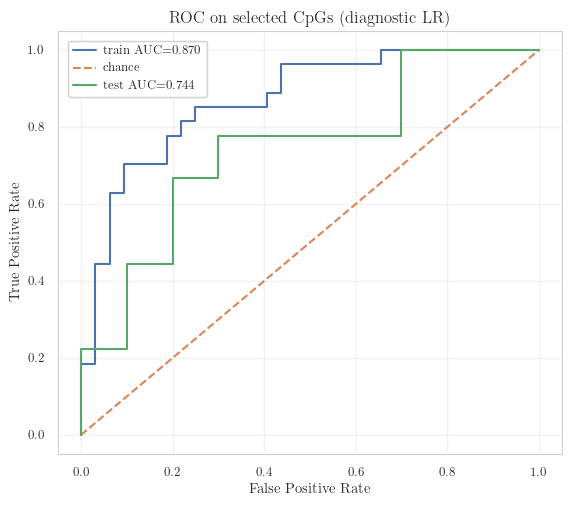

In [78]:
# ============================================================
# PLOTS for selected 50 CpGs (M-values): Heatmap(Ward), PCA, Boxplots top-10 |ΔM|, ROC(train/test)
# Autodetects common variable names.
# Requirements: numpy, matplotlib, scipy, sklearn
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import mannwhitneyu

g = globals()

def pick_first(names):
    for n in names:
        if n in g and g[n] is not None:
            return n, g[n]
    return None, None

# --- autodetect matrices/labels ---
Xtr_name, Xtr = pick_first(["X_tr", "X_train", "X_train_full", "Xtr", "XTR", "X"])
ytr_name, ytr = pick_first(["y_tr", "y_train", "y_train_full", "ytr", "Ytr", "y"])

Xte_name, Xte = pick_first(["X_te", "X_test", "X_test_full", "Xte", "XTE"])
yte_name, yte = pick_first(["y_te", "y_test", "y_test_full", "yte", "Yte"])

if Xtr is None or ytr is None:
    raise NameError(
        "Non trovo le variabili train.\n"
        "Rinomina oppure crea: X_tr, y_tr (e opzionali X_te, y_te).\n"
        "Oppure assicurati di avere una tra: X_train / X_train_full e y_train / y_train_full."
    )

Xtr = np.asarray(Xtr, float)
ytr = np.asarray(ytr)

if Xte is not None and yte is not None:
    Xte = np.asarray(Xte, float)
    yte = np.asarray(yte)
else:
    Xte, yte = None, None

# --- autodetect CpG names / selection indices ---
selected_cpgs = g.get("selected_cpgs", None)
selected_idx  = g.get("selected_idx", None)
feature_names = g.get("cpg_cols_train", None)  # sometimes you have all CpG names here

# If Xtr has more than 50 features, try to slice to selected 50 using selected_idx
if Xtr.shape[1] != 50:
    if selected_idx is not None:
        selected_idx = np.asarray(selected_idx, int).ravel()
        Xtr = Xtr[:, selected_idx]
        if Xte is not None:
            Xte = Xte[:, selected_idx]
        if feature_names is not None:
            feature_names = list(feature_names)
            selected_cpgs = [feature_names[i] for i in selected_idx]
    else:
        print(f"[WARN] X has {Xtr.shape[1]} features, not 50, and selected_idx not found. Plots will use all features.")

# If we still don't have CpG labels, create generic ones
if selected_cpgs is None and Xtr.shape[1] == 50:
    selected_cpgs = [f"CpG_{i}" for i in range(50)]

print(f"[USING] train: {Xtr_name} shape={Xtr.shape}, {ytr_name} shape={ytr.shape}")
if Xte is not None:
    print(f"[USING] test : {Xte_name} shape={Xte.shape}, {yte_name} shape={yte.shape}")
print(f"[USING] CpGs : {'selected_cpgs' if selected_cpgs is not None else 'generic'}")

# --- normalize labels for consistent mapping ---
classes = np.unique(ytr)
if classes.size != 2:
    print("[WARN] Labels are not binary. Boxplots/ROC will be skipped where necessary.")

# Standardize for PCA/clustering distances (not for heatmap values)
Ztr = (Xtr - Xtr.mean(axis=0)) / (Xtr.std(axis=0) + 1e-12)

# ============================================================
# 1) HEATMAP with Ward clustering (rows & cols)
# ============================================================
row_link = linkage(pdist(Ztr, metric="euclidean"), method="ward")
row_order = leaves_list(row_link)

col_link = linkage(pdist(Ztr.T, metric="euclidean"), method="ward")
col_order = leaves_list(col_link)

X_ord = Xtr[row_order][:, col_order]
y_ord = ytr[row_order]

cls_to_int = {c:i for i,c in enumerate(np.unique(ytr))}
y_int = np.vectorize(cls_to_int.get)(y_ord)

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[0.02, 0.98], wspace=0.02)
ax_side = fig.add_subplot(gs[0,0])
ax_hm   = fig.add_subplot(gs[0,1])

ax_side.imshow(y_int.reshape(-1,1), aspect="auto")
ax_side.set_xticks([]); ax_side.set_yticks([])
ax_side.set_title("Y", fontsize=10)

im = ax_hm.imshow(X_ord, aspect="auto")
ax_hm.set_title("Heatmap (samples × features) — Ward clustering (rows/cols)", fontsize=12)
ax_hm.set_xlabel("CpGs (clustered)")
ax_hm.set_ylabel("Samples (clustered)")

if selected_cpgs is not None and len(selected_cpgs) == Xtr.shape[1]:
    cpg_ord = np.array(selected_cpgs, dtype=object)[col_order]
    tick_idx = np.arange(0, len(cpg_ord), max(1, len(cpg_ord)//10))
    ax_hm.set_xticks(tick_idx)
    ax_hm.set_xticklabels(cpg_ord[tick_idx], rotation=90, fontsize=7)
else:
    ax_hm.set_xticks([])

cbar = fig.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.01)
cbar.set_label("M-value")
plt.show()

# ============================================================
# 2) PCA on selected CpGs (train; overlay test if available)
# ============================================================
pca = PCA(n_components=2, random_state=0)
Xtr_p = pca.fit_transform(Ztr)

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111)

for c in np.unique(ytr):
    m = (ytr == c)
    ax.scatter(Xtr_p[m,0], Xtr_p[m,1], label=f"train: {c}", alpha=0.8)

if Xte is not None and yte is not None:
    Zte = (Xte - Xtr.mean(axis=0)) / (Xtr.std(axis=0) + 1e-12)
    Xte_p = pca.transform(Zte)
    for c in np.unique(yte):
        m = (yte == c)
        ax.scatter(Xte_p[m,0], Xte_p[m,1], marker="x", label=f"test: {c}", alpha=0.9)

ax.set_title("PCA on selected CpGs (M-values)", fontsize=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(loc="best", fontsize=9)
plt.show()

# ============================================================
# 3) BOXPLOTS top-10 CpGs by |ΔM| (train) + MWU p-values
# ============================================================
if classes.size == 2:
    c0, c1 = classes[0], classes[1]
    X0 = Xtr[ytr == c0]
    X1 = Xtr[ytr == c1]

    dM = np.median(X1, axis=0) - np.median(X0, axis=0)
    top10 = np.argsort(-np.abs(dM), kind="mergesort")[:10]

    fig = plt.figure(figsize=(13, 4.8))
    ax = fig.add_subplot(111)

    data0 = [X0[:, j] for j in top10]
    data1 = [X1[:, j] for j in top10]

    pos0 = np.arange(len(top10)) * 3.0
    pos1 = pos0 + 1.0

    ax.boxplot(data0, positions=pos0, widths=0.8)
    ax.boxplot(data1, positions=pos1, widths=0.8)

    if selected_cpgs is not None and len(selected_cpgs) == Xtr.shape[1]:
        names = [selected_cpgs[j] for j in top10]
    else:
        names = [f"feat_{j}" for j in top10]

    ax.set_xticks(pos0 + 0.5)
    ax.set_xticklabels(names, rotation=60, ha="right", fontsize=9)
    ax.set_title("Top-10 CpGs by $|\Delta M|$ (train): boxplots by class", fontsize=12)
    ax.set_ylabel("M-value")

    y_top = ax.get_ylim()[1]
    for k, j in enumerate(top10):
        try:
            p = mannwhitneyu(X0[:, j], X1[:, j], alternative="two-sided").pvalue
            txt = f"$|\Delta M|$={dM[j]:+.2f}\nMWU p={p:.1e}"
        except Exception:
            txt = f"$|\Delta M|$={dM[j]:+.2f}"
        ax.text(pos0[k] + 0.5, y_top, txt, ha="center", va="top", fontsize=8)

    ax.legend([plt.Line2D([0],[0]), plt.Line2D([0],[0])], [str(c0), str(c1)], loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("[BOXPLOT] Skipped: labels not binary.")

# ============================================================
# 4) ROC (train and test) — diagnostic LogisticRegression
# ============================================================
if classes.size == 2:
    map01 = {classes[0]:0, classes[1]:1}
    ytr01 = np.vectorize(map01.get)(ytr)

    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(max_iter=3000, solver="lbfgs"))
    ])
    clf.fit(Xtr, ytr01)

    p_tr = clf.predict_proba(Xtr)[:, 1]
    fpr_tr, tpr_tr, _ = roc_curve(ytr01, p_tr)
    auc_tr = roc_auc_score(ytr01, p_tr)

    fig = plt.figure(figsize=(6.5, 5.5))
    ax = fig.add_subplot(111)
    ax.plot(fpr_tr, tpr_tr, label=f"train AUC={auc_tr:.3f}")
    ax.plot([0,1],[0,1], linestyle="--", label="chance")

    if Xte is not None and yte is not None:
        yte01 = np.vectorize(map01.get)(yte)
        p_te = clf.predict_proba(Xte)[:, 1]
        fpr_te, tpr_te, _ = roc_curve(yte01, p_te)
        auc_te = roc_auc_score(yte01, p_te)
        ax.plot(fpr_te, tpr_te, label=f"test AUC={auc_te:.3f}")

    ax.set_title("ROC on selected CpGs (diagnostic LR)", fontsize=12)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="best", fontsize=9)
    plt.show()
else:
    print("[ROC] Skipped: labels not binary.")
